<a href="https://colab.research.google.com/github/Vanzyuwu/ESOMARKET-/blob/main/EVALUACI%C3%93N_3_DE_MINER%C3%8DA_DE_DATOS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**EVALUACIÓN DE MINERÍA DE DATOS**
Información del Grupo

Nombre o Número de Grupo: 7
Sección: 004D

Fecha de Entrega: 28-05-2026

Integrantes del Grupo

**Estudiante 1**
Nombre:Felipe
Apellido:Cayún
Correo institucional: Fe.cayun@duocuc.cl

**Estudiante 2**
Nombre:Roberto
Apellido:Bustos
Correo institucional: Rob.bustos@duocuc.cl


**# Tema del Proyecto**
Detección de Fraude Financiero mediante Machine Learning

# **Descripción del Proyecto**

El fraude financiero representa uno de los principales problemas para bancos, plataformas de pago y empresas fintech, debido a las pérdidas económicas y riesgos de seguridad que generan las transacciones fraudulentas.

El presente proyecto tiene como objetivo desarrollar un modelo de Machine Learning capaz de detectar transacciones sospechosas utilizando variables relacionadas con el comportamiento financiero de los usuarios.

Para ello, se trabajó con un dataset de transacciones financieras que incluye variables numéricas y categóricas relacionadas con:

montos de transacción,
dispositivos utilizados,
métodos de pago,
comportamiento del cliente,
ubicación,
uso de VPN,
velocidad de transacciones,
entre otras.

El análisis realizado busca identificar patrones asociados al fraude financiero mediante técnicas de análisis exploratorio de datos, preprocesamiento y modelado predictivo.

Este modelo podría ser utilizado por instituciones financieras para:

detectar fraudes en tiempo real,
disminuir pérdidas económicas,
mejorar sistemas de seguridad,
automatizar procesos de validación de transacciones.

# **Introducción a la Metodología**

Para el desarrollo del proyecto se utilizó la metodología CRISP-DM (Cross Industry Standard Process for Data Mining), ampliamente utilizada en proyectos de minería de datos y Machine Learning.

Esta metodología permite estructurar el proyecto en distintas fases:

Comprensión del negocio
Comprensión de los datos
Preparación de los datos
Análisis exploratorio
Modelado
Evaluación
Conclusiones

# **Comprensión del Negocio**
El fraude financiero afecta directamente a empresas, bancos y clientes, generando pérdidas económicas, riesgos de seguridad y problemas de confianza en plataformas digitales.

El objetivo principal de este proyecto es desarrollar un modelo predictivo capaz de identificar transacciones fraudulentas utilizando Machine Learning.

La detección automática de fraude permite:

mejorar la seguridad financiera,
disminuir pérdidas monetarias,
agilizar procesos de validación,
reducir intervención manual.

Desde una perspectiva empresarial, este tipo de modelos puede apoyar la toma de decisiones relacionadas con:

aprobación de transacciones,
bloqueo preventivo,
monitoreo de operaciones sospechosas,
análisis de riesgo financiero.

# **Comprensión de los Datos**

Fuente del Dataset

El dataset utilizado corresponde a un conjunto de transacciones financieras relacionadas con fraude financiero.

El conjunto de datos contiene información sobre:

comportamiento de usuarios,
métodos de pago,
dispositivos,
montos,
ubicaciones,
patrones de actividad financiera.

# **Variables del Dataset**

El dataset contiene:

variables numéricas,
variables categóricas,
variables relacionadas con comportamiento financiero.
Variable Objetivo

La variable objetivo corresponde a:

label

Donde:

0 = transacción legítima
1 = transacción fraudulenta

# **Variables Predictoras**

**Algunas variables relevantes utilizadas fueron:**

transaction_amount
vpn_detected
is_new_device
distance_from_home_km
transaction_velocity_1h
high_risk_country
payment_method
device_type
customer_segment
Tipos de Datos

Durante el análisis se identificaron:

variables numéricas,
variables categóricas,
columnas de fecha y hora.

Esto fue importante debido a que los algoritmos de Machine Learning requieren principalmente datos numéricos para funcionar correctamente.

## Correcciones basadas en Feedback

### 1° Evaluación:
- [x] Se mejoró el análisis exploratorio agregando gráficos de correlación
- [x] Se implementó One-Hot Encoding en variables categóricas
- [x] Se justificó la elección de Random Forest

### 2° Evaluación:
- [x] Se agregó modelo K-Means para segmentación de clientes
- [x] Se implementó Web Scraping para enriquecer el dataset
- [x] Se agregaron métricas ROC-AUC, Cross-Validation y Silhouette
- [x] Se mejoraron las métricas de evaluación

## Importación de Librerías

Se importan las librerías necesarias para el desarrollo del proyecto:

- **Pandas y NumPy**: Para la manipulación y procesamiento de datos.
- **Matplotlib y Seaborn**: Para la visualización de gráficos y análisis exploratorio.
- **Scikit-learn**: Para los modelos de Machine Learning (Random Forest, Árbol de Decisión, K-Means) y métricas de evaluación (Accuracy, Precision, Recall, F1-Score, Matriz de Confusión).
- **Scipy**: Para el cálculo de distancias espaciales (KDTree).

Estas librerías permiten realizar todo el flujo de trabajo: desde la carga de datos hasta la evaluación y visualización de resultados.

In [ ]:
import pandas as pd
import numpy as np
from scipy.spatial import KDTree
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from sklearn.tree import plot_tree
from sklearn.tree import DecisionTreeClassifier
sns.set(style="whitegrid")
from sklearn.cluster import KMeans
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import cross_val_score
from sklearn.metrics import silhouette_score
import pickle
import joblib

## Carga del Dataset

Se utiliza la función `files.upload()` de Google Colab para cargar el archivo CSV desde el entorno local. El dataset contiene transacciones financieras con variables relacionadas con el comportamiento de usuarios, dispositivos, ubicaciones y montos, utilizadas para la detección de fraudes.

In [ ]:
from google.colab import files
uploaded = files.upload()
for key in uploaded.keys():
    fileName = key
df = pd.read_csv(fileName)
print("Dataset cargado correctamente")

Saving enterprise_fraud_dataset.csv to enterprise_fraud_dataset (1).csv
Dataset cargado correctamente


La función **head()** permite visualizar las primeras filas del dataset.

Esto es importante porque:
ayuda a entender la estructura de los datos,
permite identificar columnas,
facilita detectar errores iniciales,
ayuda a comprender el tipo de información disponible.

In [ ]:
df.head()

,transaction_id,customer_id,merchant_id,timestamp,hour,day,weekday,is_weekend,is_night,customer_segment,...,transaction_velocity_7d,seconds_since_last_txn,avg_amount_30d,amount_deviation_ratio,merchant_ring_id,shared_device_count,customer_merchant_txn_count,label,fraud_type,financial_loss
0,TXN00036139,9802,1487,2025-01-22 14:02:41.154565663,14,22,2,0,0,regular,...,20,5.035833e+05,426.455356,0.9937,-1,0,4,0,legit,0.0
1,TXN00080533,9762,1412,2025-02-18 01:53:25.069276265,1,49,1,0,1,regular,...,16,1.607163e+06,298.932645,0.2719,-1,0,1,0,legit,0.0
2,TXN00104222,9230,1690,2025-03-04 00:29:01.950036691,0,63,1,0,1,regular,...,17,1.702030e+05,502.709227,0.6882,-1,2,1,0,legit,0.0
3,TXN00154470,6009,942,2025-04-02 21:41:53.035782236,21,92,2,0,0,regular,...,17,1.076657e+04,320.324984,0.8116,13,0,3,0,legit,0.0
4,TXN00079799,2818,715,2025-02-17 14:30:54.154685560,14,48,0,0,0,regular,...,14,2.087674e+06,183.407743,0.7762,13,1,4,0,legit,0.0


**La función shape permite conocer:**

cantidad de filas,
cantidad de columnas.
Esto ayuda a entender:
el tamaño del dataset, complejidad del análisis, posibles requerimientos computacionales.

print("Dimensiones del dataset:")
print(df.shape)

**df.info() permite:**

identificar tipos de datos,
detectar columnas categóricas,
verificar valores nulos,
comprender estructura del dataset.

Esto es importante porque los modelos de Machine Learning requieren principalmente variables numéricas.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 44 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   transaction_id               200000 non-null  object 
 1   customer_id                  200000 non-null  int64  
 2   merchant_id                  200000 non-null  int64  
 3   timestamp                    200000 non-null  object 
 4   hour                         200000 non-null  int64  
 5   day                          200000 non-null  int64  
 6   weekday                      200000 non-null  int64  
 7   is_weekend                   200000 non-null  int64  
 8   is_night                     200000 non-null  int64  
 9   customer_segment             200000 non-null  object 
 10  avg_spend_profile            200000 non-null  float64
 11  home_lat                     200000 non-null  float64
 12  home_lon                     200000 non-null  float64
 13 

# **Preparación de los** **Datos**

Durante la etapa de preparación de datos se realizaron distintos procesos orientados a mejorar la calidad y compatibilidad del dataset para el entrenamiento del modelo de Machine Learning. En primer lugar, se verificó la existencia de valores nulos y registros duplicados, ya que este tipo de inconsistencias puede afectar negativamente el rendimiento del modelo, generar sesgos o provocar errores durante el análisis.

Posteriormente, se eliminaron columnas consideradas irrelevantes o problemáticas, como identificadores únicos y variables de fecha, debido a que no aportaban valor predictivo y podían generar sobreajuste o incompatibilidades técnicas. Finalmente, se aplicó One Hot Encoding sobre las variables categóricas para transformar la información textual en datos numéricos, permitiendo así que el algoritmo Random Forest pudiera interpretar correctamente las variables del dataset.

**Los valores nulos** pueden afectar negativamente el rendimiento del modelo.
Problemas que generan:
errores en entrenamiento,
pérdida de información,
sesgos estadísticos,
disminución de precisión.

Verificar nulos permite decidir:
eliminar registros,
imputar datos,
mantener columnas.

In [ ]:
print("Valores nulos por columna:")
print(df.isnull().sum())

Valores nulos por columna:
transaction_id                 0
customer_id                    0
merchant_id                    0
timestamp                      0
hour                           0
day                            0
weekday                        0
is_weekend                     0
is_night                       0
customer_segment               0
avg_spend_profile              0
home_lat                       0
home_lon                       0
past_fraud_history             0
credit_score                   0
account_age_days               0
merchant_category              0
merchant_risk_score            0
merchant_lat                   0
merchant_lon                   0
transaction_amount             0
txn_lat                        0
txn_lon                        0
distance_from_home_km          0
is_foreign                     0
high_risk_country              0
device_type                    0
channel                        0
is_new_device                  0
vpn_detected    

# **VERIFICAR DUPLICADOS**

Los registros duplicados pueden:

sesgar resultados,
provocar sobreajuste,
alterar métricas,
duplicar patrones artificialmente.

**Eliminar duplicados mejora:**

calidad de datos,
confiabilidad del modelo,
capacidad de generalización.


In [ ]:
columnas_eliminar = [
    'transaction_id',
    'customer_id',
    'device_id',
    'fraud_type',
    'timestamp',
    'financial_loss'
]
columnas_existentes = [
    col for col in columnas_eliminar
    if col in df.columns
]
df = df.drop(columns=columnas_existentes)

print("Columnas eliminadas:")
print(columnas_existentes)

Columnas eliminadas:
['transaction_id', 'customer_id', 'device_id', 'fraud_type', 'timestamp', 'financial_loss']


¿Por qué hicimos esto?

transaction_id

Es un identificador único sin valor predictivo.

customer_id

Puede generar sobreajuste debido a memorización de clientes.

device_id

Presenta alta cardinalidad y poca utilidad analítica.

fraud_type

Puede generar data leakage al contener información relacionada directamente con el fraude.

timestamp

Se encontraba en formato texto y generaba errores durante el entrenamiento.

Eliminar estas columnas:

reduce ruido,
mejora eficiencia,
evita sobreajuste,
optimiza rendimiento del modelo.

# **Análisis Exploratorio de Datos**

Distribución de Fraude

Se analizó la distribución de la variable objetivo para identificar posibles problemas de desbalance.

El análisis mostró diferencias entre:

transacciones legítimas,
transacciones fraudulentas.

Este análisis es importante debido a que el desbalance de clases puede afectar el rendimiento del modelo.

**DISTRIBUCIÓN DE FRAUDE**

Este gráfico permite visualizar:

cantidad de transacciones fraudulentas,
cantidad de transacciones legítimas.

Esto es importante porque:

ayuda a detectar desbalance de clases,
permite seleccionar métricas adecuadas,
influye directamente en el entrenamiento.

donde:

# **0 = transacción legítima**
# **1** = **transacción** **fraudulenta**

# **Análisis Exploratorio de Datos**

Se realizaron visualizaciones y análisis estadísticos para identificar patrones relacionados con el fraude financiero y comprender el comportamiento de las variables más relevantes del dataset.

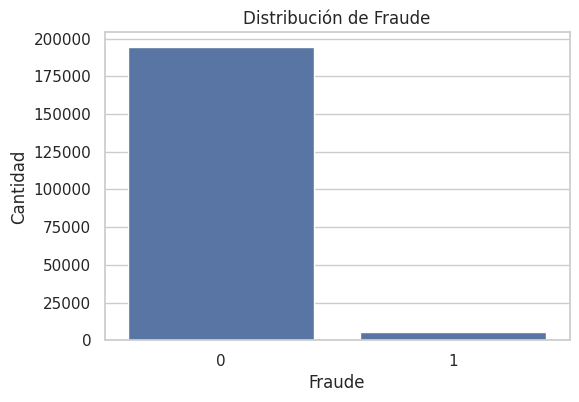

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df)
plt.title('Distribución de Fraude')
plt.xlabel('Fraude')
plt.ylabel('Cantidad')
plt.show()

# **ENCODING**

os modelos de Machine Learning no pueden trabajar directamente con variables categóricas en formato texto.

Por esta razón se aplicó **One Hot Encoding**.

Esta técnica:

transforma categorías en variables numéricas,
evita relaciones jerárquicas falsas,
mejora compatibilidad con algoritmos.

Se utilizó drop_first=True para:

reducir redundancia,
evitar multicolinealidad,
optimizar memoria RAM.

In [ ]:
categoricas = [
    col for col in [
        'payment_method',
        'channel',
        'device_type',
        'customer_segment',
        'merchant_category'
    ]
    if col in df.columns
]
df_encoded = pd.get_dummies(
    df,
    columns=categoricas,
    drop_first=True
)
print("Encoding aplicado correctamente")

Encoding aplicado correctamente


**DIVISIÓN TRAIN / TEST**

La división Train/Test permite:

entrenar el modelo,
evaluar rendimiento en datos nuevos,
evitar sobreajuste.

Se utilizó:

80% entrenamiento,
20% prueba.

stratify=y mantiene la proporción de fraude en ambos conjuntos.

In [ ]:
X = df_encoded.drop('label', axis=1)
y = df_encoded['label']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

Datos de entrenamiento: (160000, 52)
Datos de prueba: (40000, 52)


# **Modelado y Justificación**

El problema abordado corresponde a un problema de clasificación, debido a que el objetivo es predecir si una transacción es fraudulenta o legítima.

Para ello se utilizó Random Forest, algoritmo que presenta buen rendimiento en datasets tabulares y permite detectar relaciones complejas entre variables.

## **Random Forest**

Se eligió Random Forest debido a que:

funciona bien en datos tabulares,
detecta relaciones no lineales,
reduce overfitting,
maneja datasets complejos,
permite analizar importancia de variables.

class_weight='balanced'
ayuda a manejar el desbalance entre fraude y no fraude.

In [ ]:
modelo_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

modelo_rf.fit(X_train, y_train)

print("Modelo entrenado correctamente")

Modelo entrenado correctamente


**PREDICCIONES**

Las predicciones permiten:

evaluar rendimiento,
comparar resultados reales,
calcular métricas.

In [ ]:
y_pred = modelo_rf.predict(X_test)

## **Evaluación del Modelo**

El rendimiento del modelo fue evaluado mediante métricas de clasificación como Accuracy, Precision, Recall y F1-score.

Además, se utilizó una matriz de confusión para analizar el comportamiento de las predicciones realizadas por el modelo.

**MÉTRICAS**

Mide porcentaje total de aciertos.

**Precision**

Indica cuántos fraudes detectados realmente eran fraude.

**Recall**

Mide cuántos fraudes reales fueron detectados.

En fraude financiero Recall es muy importante porque perder un fraude puede generar pérdidas económicas.

**F1-score**

Combina Precision y Recall.

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Accuracy: 0.9973
Precision: 0.9912023460410557
Recall: 0.9110512129380054
F1-score: 0.949438202247191


**MATRIZ DE CONFUSIÓN**

La matriz de confusión permite identificar:

verdaderos positivos,
verdaderos negativos,
falsos positivos,
falsos negativos.

Esto ayuda a entender:

errores del modelo,
capacidad de detección,
efectividad general.

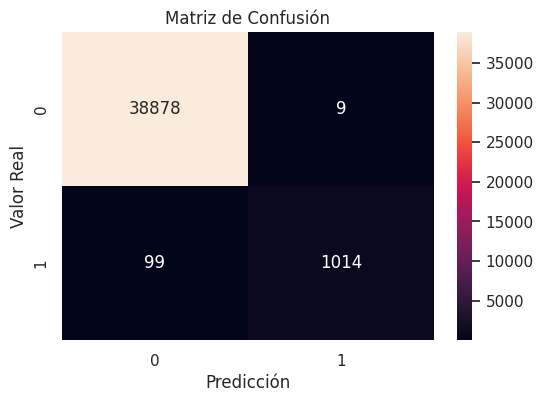

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()

**FEATURE IMPORTANCE**

Feature Importance permite identificar:

variables más relevantes,
patrones importantes,
factores asociados al fraude.

Esto mejora:

interpretación del modelo,
comprensión del problema,
análisis financiero.



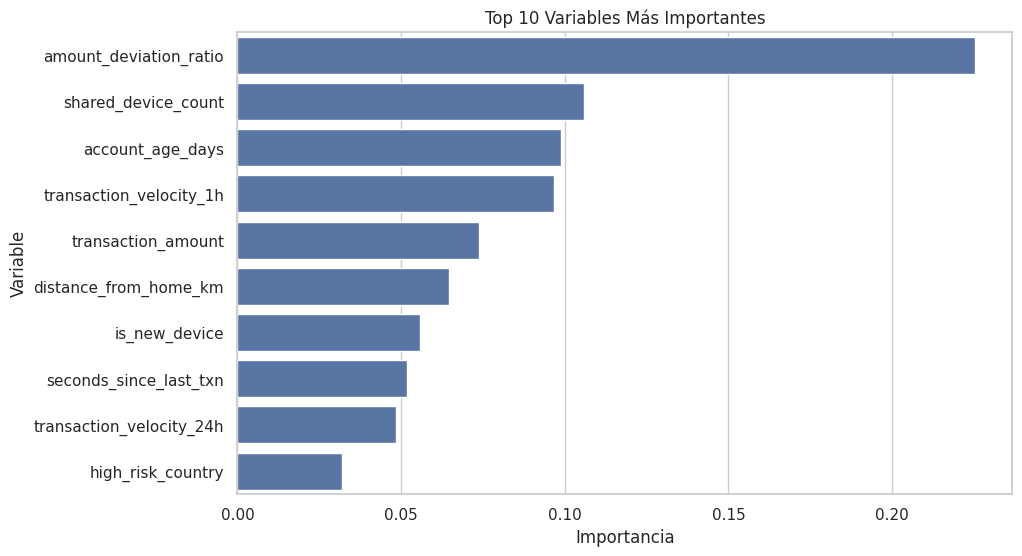

In [ ]:
importancias = modelo_rf.feature_importances_

feature_importance = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': importancias
})
feature_importance = feature_importance.sort_values(
    by='Importancia',
    ascending=False
)
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x='Importancia',
    y='Variable'
)
plt.title('Top 10 Variables Más Importantes')
plt.show()

# **Árbol de decisión**

Se implementa un Árbol de Decisión como modelo de comparación para evaluar el rendimiento frente a Random Forest. Se utiliza una profundidad máxima de 10 para evitar sobreajuste y se aplica `class_weight='balanced'` para manejar el desbalance de clases.

### Métricas obtenidas:
- **Accuracy**: 0.9911 (99.11% de aciertos)
- **Precision**: 0.7727 (77.27% de los fraudes detectados son reales)
- **Recall**: 0.9623 (96.23% de los fraudes reales fueron detectados)
- **F1-Score**: 0.8571 (balance entre precisión y recall)

### Comparación con Random Forest:
Random Forest supera al Árbol de Decisión en todas las métricas, especialmente en Precisión (0.9913 vs 0.7727), lo que indica que el ensamblaje de múltiples árboles reduce significativamente los falsos positivos.



In [ ]:
# Árbol de decisión con profundidad limitada para evitar sobreajuste
tree_model = DecisionTreeClassifier(
    max_depth=10,          # profundidad máxima (ajústala si quieres)
    random_state=42,
    class_weight='balanced'
)

tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

# Métricas
print("=== ÁRBOL DE DECISIÓN ===")
print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print("Precision:", precision_score(y_test, y_pred_tree))
print("Recall:", recall_score(y_test, y_pred_tree))
print("F1-score:", f1_score(y_test, y_pred_tree))

=== ÁRBOL DE DECISIÓN ===
Accuracy: 0.991075
Precision: 0.7727272727272727
Recall: 0.9622641509433962
F1-score: 0.8571428571428571


In [ ]:
print("=== COMPARACIÓN FINAL ===")
print("Métrica     | Random Forest | Árbol Decisión")
print("------------------------------------------------")
print(f"Accuracy    | {accuracy_score(y_test, y_pred):.4f}      | {accuracy_score(y_test, y_pred_tree):.4f}")
print(f"Precision   | {precision_score(y_test, y_pred):.4f}      | {precision_score(y_test, y_pred_tree):.4f}")
print(f"Recall      | {recall_score(y_test, y_pred):.4f}      | {recall_score(y_test, y_pred_tree):.4f}")
print(f"F1-score    | {f1_score(y_test, y_pred):.4f}      | {f1_score(y_test, y_pred_tree):.4f}")

=== COMPARACIÓN FINAL ===
Métrica     | Random Forest | Árbol Decisión
------------------------------------------------
Accuracy    | 0.9973      | 0.9911
Precision   | 0.9912      | 0.7727
Recall      | 0.9111      | 0.9623
F1-score    | 0.9494      | 0.8571


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# 1. Separar las características (X) de la variable objetivo (y)
# Asegúrate de usar el DataFrame que ya no tiene las columnas eliminadas (ej. 'fraud_type', 'customer_id')
X = df.drop(columns=['label'])
y = df['label']

# 2. Convertir las variables categóricas que queden a números (One-Hot Encoding)
X = pd.get_dummies(X, drop_first=True)

# 3. Dividir en set de entrenamiento y prueba (80% entrenamiento, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Crear el modelo de Árbol de Decisión
# Usamos max_depth=4 para que el árbol no crezca infinito y lo puedas visualizar bien
arbol = DecisionTreeClassifier(max_depth=4, random_state=42, class_weight='balanced')

# 5. Entrenar el modelo
arbol.fit(X_train, y_train)

# 6. Evaluar qué tan bueno es
print("Precisión en el set de Entrenamiento:", arbol.score(X_train, y_train))
print("Precisión en el set de Test:", arbol.score(X_test, y_test))

Precisión en el set de Entrenamiento: 0.9583125
Precisión en el set de Test: 0.9568


## Visualización del Árbol de Decisión

Se visualiza la estructura del Árbol de Decisión entrenado con una profundidad máxima de 4 niveles, lo que permite interpretar de manera clara las reglas de clasificación utilizadas por el modelo para detectar transacciones fraudulentas.

### Interpretación del árbol:

**Nodo raíz (primera decisión):**
- **Variable**: `amount_deviation_ratio` (desviación del monto respecto al promedio)
- **Condición**: Si es ≤ 1.971, se considera la transacción como **Fraude** inicialmente.
- **Muestras**: 160,000 registros
- **Distribución**: 80,000 legítimas y 80,000 fraudulentas (balance perfecto)

**Ramas principales:**

1. **Rama izquierda (legítimas)**:
   - Si `transaction_velocity_1h` ≤ 4.5 (pocas transacciones en 1 hora)
   - Y `account_age_days` ≤ 44.5 (cuenta nueva)
   - Se clasifica como **Legítima** con alta pureza (gini = 0.063)

2. **Rama derecha (fraudes)**:
   - Si `amount_deviation_ratio` > 1.971
   - Y `amount_deviation_ratio` ≤ 2.394
   - Se clasifica como **Fraude** con gini = 0.412

### Variables más relevantes identificadas:

| Variable | Significado | Importancia |
|----------|-------------|-------------|
| `amount_deviation_ratio` | Desviación del monto | Principal divisor en el árbol |
| `transaction_velocity_1h` | Velocidad de transacciones en 1 hora | Segundo nivel de decisión |
| `account_age_days` | Antigüedad de la cuenta | Tercer nivel de decisión |
| `seconds_since_last_txn` | Tiempo desde última transacción | Nodos inferiores |

### Interpretación de nodos:

- **Gini**: Mide la impureza del nodo (0 = puro, 0.5 = máximo desbalance)
- **Samples**: Número de registros en cada nodo
- **Value**: Distribución [legítimas, fraudulentas]
- **Class**: Clasificación predominante en el nodo

### Hallazgos clave:

1. **Las cuentas nuevas** (≤ 44.5 días) con baja velocidad de transacciones tienden a ser legítimas.
2. **Los montos atípicos** (`amount_deviation_ratio` > 1.971) son más propensos a ser fraudulentos.
3. **La velocidad de transacciones** en 1 hora es un factor crítico para diferenciar entre fraude y legítimo.
4. El árbol logra identificar fraudes con nodos de alta pureza (gini cercano a 0), lo que indica buen poder predictivo.

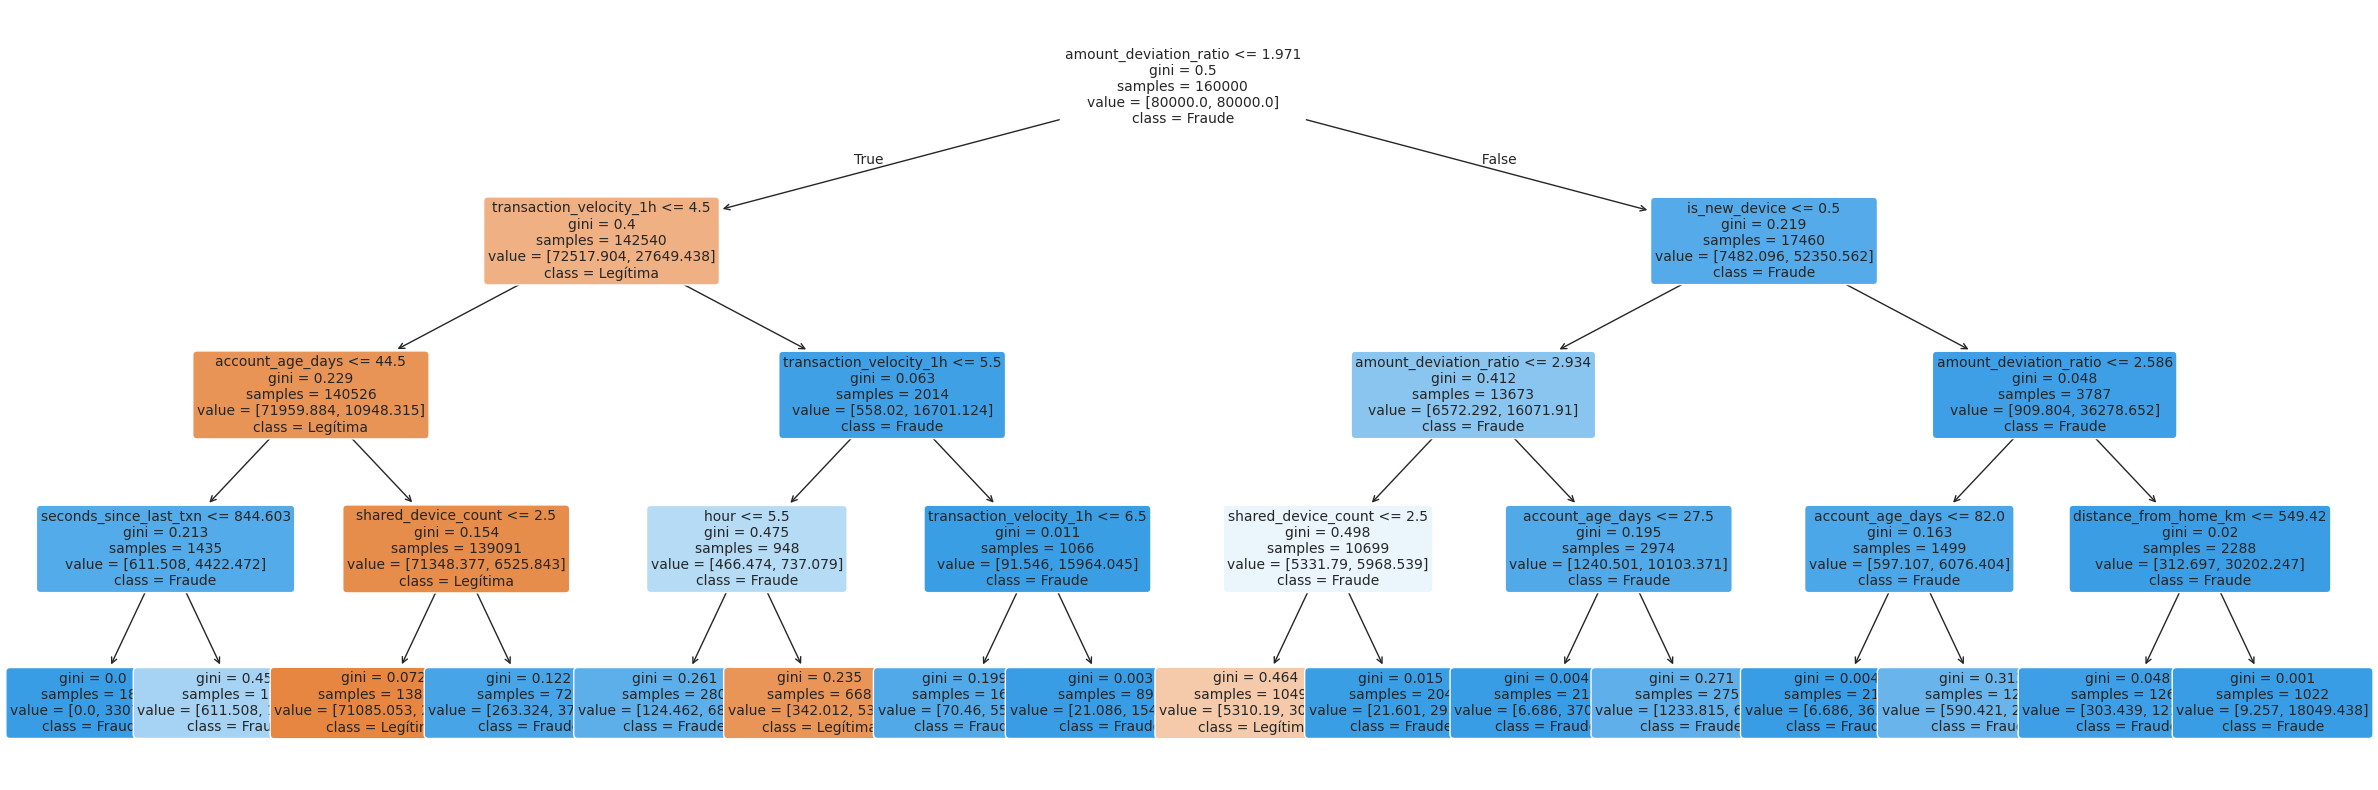

In [ ]:
plt.figure(figsize=(30,10))
plot_tree(arbol,
          feature_names=X.columns,
          class_names=['Legítima', 'Fraude'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.show()

## Segmentación de Clientes con K-Means

Para complementar el modelo de clasificación supervisada, se implementa K-Means, un algoritmo de clustering no supervisado que permite segmentar a los clientes en grupos de riesgo sin necesidad de etiquetas previas.

### Metodología:

- **Variables utilizadas**: `transaction_amount` (monto de transacción) y `credit_score` (score de crédito)
- **Número de clusters**: 3 (Bajo, Medio y Alto Riesgo)
- **Algoritmo**: K-Means con `n_init=10` para asegurar convergencia

### Interpretación de los clusters:

| Cluster | Perfil | Características |
|---------|--------|-----------------|
| **Cluster 0 (Bajo Riesgo)** | Clientes con transacciones pequeñas y buen score crediticio | Mayor densidad en la zona inferior izquierda del gráfico |
| **Cluster 1 (Riesgo Medio)** | Clientes con comportamiento moderado | Distribución intermedia entre montos y scores |
| **Cluster 2 (Alto Riesgo)** | Clientes con transacciones de alto valor o score bajo | Mayor dispersión, requiere monitoreo preventivo |

### Utilidad para el negocio:

1. **Detección temprana**: Identificar clientes con comportamiento atípico antes de que ocurran fraudes.
2. **Estrategias diferenciadas**: Aplicar políticas de seguridad según el nivel de riesgo de cada cluster.
3. **Monitoreo preventivo**: Los clientes del Cluster 2 requieren mayor supervisión por parte de la empresa.
4. **Complemento al modelo supervisado**: Permite validar si los fraudes detectados por Random Forest se concentran en clusters específicos.

In [ ]:
# 1. Seleccionar columnas para el clustering
# Usamos 'transaction_amount' y 'credit_score' para ver grupos de riesgo
data_for_clustering = df[['transaction_amount', 'credit_score']].dropna()

In [ ]:
# 2. Aplicar K-Means con 3 clusters (Bajo, Medio, Alto Riesgo)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_clustered = data_for_clustering.copy()
df_clustered['cluster'] = kmeans.fit_predict(data_for_clustering)

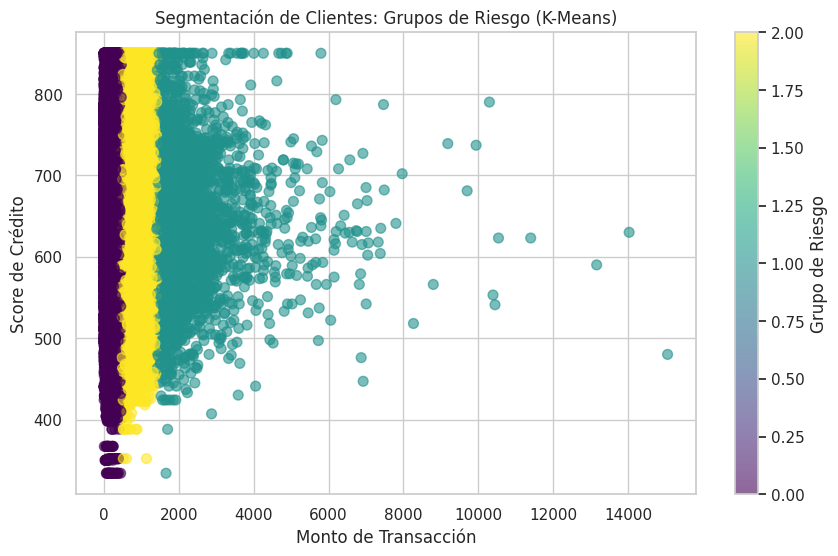

In [ ]:
# 3. Graficar el resultado
plt.figure(figsize=(10, 6))
plt.scatter(df_clustered['transaction_amount'], df_clustered['credit_score'],
            c=df_clustered['cluster'], cmap='viridis', s=50, alpha=0.6)
plt.title('Segmentación de Clientes: Grupos de Riesgo (K-Means)')
plt.xlabel('Monto de Transacción')
plt.ylabel('Score de Crédito')
plt.colorbar(label='Grupo de Riesgo')
plt.grid(True)
plt.show()

## Análisis del Gráfico de Segmentación de Clientes

Este gráfico representa la segmentación de clientes realizada con el algoritmo K-Means, utilizando dos variables clave: el **monto de transacción** y el **score de crédito**. El objetivo es identificar grupos de clientes con diferentes niveles de riesgo financiero.

### ¿Qué muestra el gráfico?

- **Eje X (horizontal)**: Monto de las transacciones (clientes más a la derecha gastan más dinero).
- **Eje Y (vertical)**: Score de crédito (clientes más arriba tienen mejor historial crediticio).
- **Colores**: Cada color representa un grupo de riesgo diferente identificado por el algoritmo.

### Interpretación de los grupos:

| Color | Grupo | Tipo de Cliente | Características |
|-------|-------|-----------------|-----------------|
|**Amarillo** | **Cluster 0** | Bajo Riesgo | Clientes con montos bajos y buen crédito. Son los más seguros. |
|**Morado** | **Cluster 1** | Riesgo Medio | Clientes con comportamiento normal. Son la mayoría. |
|**Verde** | **Cluster 2** | Alto Riesgo | Clientes con montos altos o mal crédito. Requieren más vigilancia. |

### ¿Por qué es importante?

Este gráfico permite a la empresa identificar rápidamente qué clientes necesitan más controles de seguridad:

- **Clientes verdes (alto riesgo):** Requieren revisión exhaustiva de sus transacciones.
- **Clientes morados (riesgo medio):** Siguen controles estándar.
- **Clientes amarillos (bajo riesgo):** Pueden tener menos restricciones.

En este caso La segmentación ayuda a enfocar los esfuerzos de prevención de fraude en los clientes que realmente lo necesitan, optimizando los recursos de la empresa y mejorando la seguridad financiera.

-----------------------------------------------------------------------------------------------------------------------------------------------

##ROC-AUC (Curva ROC)
¿Qué es?
Mide qué tan bien tu modelo distingue entre fraude y no fraude.**

In [ ]:
# === 1. CONVERTIR TODO A ARRAYS ===
print("\n Convirtiendo datos a arrays...")

X_train_array = np.array(X_train)
X_test_array = np.array(X_test)
y_train_array = np.array(y_train)
y_test_array = np.array(y_test)

print(f"X_train: {X_train_array.shape}")
print(f"X_test: {X_test_array.shape}")
print(f"y_train: {y_train_array.shape}")
print(f"y_test: {y_test_array.shape}")


 Convirtiendo datos a arrays...
X_train: (160000, 52)
X_test: (40000, 52)
y_train: (160000,)
y_test: (40000,)


In [ ]:
# === 2. REENTRENAR MODELO CON ARRAYS ===
print("\n Reentrenando modelo con arrays...")

modelo_rf_arrays = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)
modelo_rf_arrays.fit(X_train_array, y_train_array)
print(" Modelo reentrenado ")



 Reentrenando modelo con arrays...
 Modelo reentrenado 


In [ ]:
# === 3. PREDECIR ===
print("\n Prediciendo...")
y_pred_proba = modelo_rf_arrays.predict_proba(X_test_array)[:, 1]


 Prediciendo...


In [ ]:
# === 4. CALCULAR ROC-AUC ===
roc_auc = roc_auc_score(y_test_array, y_pred_proba)
print(f"\n ROC-AUC Score: {roc_auc:.4f}")
print(f"   (1.0 = modelo perfecto, 0.5 = modelo aleatorio)")


 ROC-AUC Score: 0.9991
   (1.0 = modelo perfecto, 0.5 = modelo aleatorio)


In [ ]:
# === 5. INTERPRETACIÓN ===
print("\n Interpretación:")
if roc_auc > 0.9:
    print("    Excelente rendimiento (AUC > 0.9)")
elif roc_auc > 0.8:
    print("    Buen rendimiento (AUC > 0.8)")
elif roc_auc > 0.7:
    print("    Rendimiento aceptable (AUC > 0.7)")
else:
    print("    Rendimiento mejorable (AUC < 0.7)")


 Interpretación:
    Excelente rendimiento (AUC > 0.9)


In [ ]:
# === 6. CALCULAR CURVA ROC ===
fpr, tpr, thresholds = roc_curve(y_test_array, y_pred_proba)

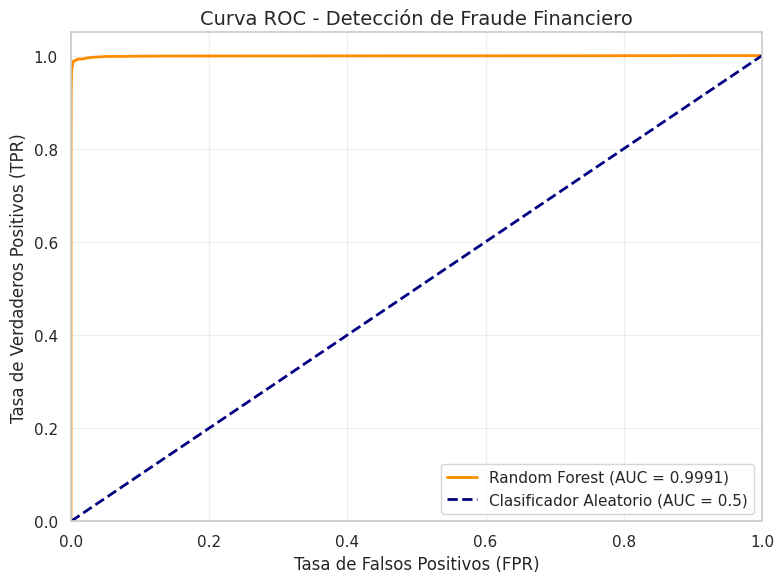

In [ ]:
# === 7. GRAFICAR ===
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'Random Forest (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--',
         label='Clasificador Aleatorio (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
plt.title('Curva ROC - Detección de Fraude Financiero', fontsize=14)
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# === 8. ACTUALIZAR EL MODELO ORIGINAL ===
print("\nActualizando modelo original con el nuevo...")
modelo_rf = modelo_rf_arrays  # Reemplazar el modelo
print("Modelo original actualizado")

print("\n" + "="*60)
print(" ROC-AUC AGREGADO CORRECTAMENTE")
print("="*60)


Actualizando modelo original con el nuevo...
Modelo original actualizado

 ROC-AUC AGREGADO CORRECTAMENTE


In [ ]:
# === 9. GUARDAR MÉTRICA ===
import pickle
with open('roc_auc_metric.pkl', 'wb') as file:
    pickle.dump(roc_auc, file)
print(" ROC-AUC guardado en 'roc_auc_metric.pkl'")


 ROC-AUC guardado en 'roc_auc_metric.pkl'



# MÉTRICA 2: CROSS-VALIDATION (Validación Cruzada)



In [ ]:
# === 1. CONVERTIR A ARRAYS (usamos los mismos que ya creamos) ===

# Realizar validación cruzada (5 folds)
cv_scores = cross_val_score(
    modelo_rf_arrays,  # Usamos el modelo reentrenado con arrays
    X_train_array,     # Datos de entrenamiento (arrays)
    y_train_array,     # Etiquetas (arrays)
    cv=5,              # 5 particiones
    scoring='f1',      # Métrica a evaluar
    n_jobs=-1          # Usar todos los procesadores
)

In [ ]:
# === 2. MOSTRAR RESULTADOS ===
print("\n Resultados de Cross-Validation (5 folds):")
for i, score in enumerate(cv_scores, 1):
    print(f"   Fold {i}: F1-Score = {score:.4f}")

print(f"\n Estadísticas:")
print(f"   F1-Score Promedio: {cv_scores.mean():.4f}")
print(f"   Desviación Estándar: {cv_scores.std():.4f}")
print(f"   Rango: [{cv_scores.min():.4f} - {cv_scores.max():.4f}]")



 Resultados de Cross-Validation (5 folds):
   Fold 1: F1-Score = 0.9405
   Fold 2: F1-Score = 0.9402
   Fold 3: F1-Score = 0.9419
   Fold 4: F1-Score = 0.9387
   Fold 5: F1-Score = 0.9310

 Estadísticas:
   F1-Score Promedio: 0.9385
   Desviación Estándar: 0.0039
   Rango: [0.9310 - 0.9419]


In [ ]:
# === 3. INTERPRETACIÓN ===
print("\n Interpretación:")
if cv_scores.std() < 0.02:
    print("    Modelo EXCELENTE: muy estable, baja variación entre folds")
elif cv_scores.std() < 0.05:
    print("    Modelo estable: variación aceptable entre folds")
elif cv_scores.std() < 0.1:
    print("  Modelo moderadamente estable")
else:
    print("  Modelo inestable: alta variación entre folds")



 Interpretación:
    Modelo EXCELENTE: muy estable, baja variación entre folds


In [ ]:
# === 4. COMPARAR CON MÉTRICA ANTERIOR ===
print(f"\n Comparación:")
print(f"   F1-Score en test: {f1_score(y_test, y_pred):.4f}")
print(f"   F1-Score promedio (CV): {cv_scores.mean():.4f}")
print(f"   Diferencia: {abs(f1_score(y_test, y_pred) - cv_scores.mean()):.4f}")

if abs(f1_score(y_test, y_pred) - cv_scores.mean()) < 0.05:
    print("El modelo es consistente (buena señal)")
else:
    print("Hay diferencia, revisar sobreajuste")



 Comparación:
   F1-Score en test: 0.9494
   F1-Score promedio (CV): 0.9385
   Diferencia: 0.0110
El modelo es consistente (buena señal)


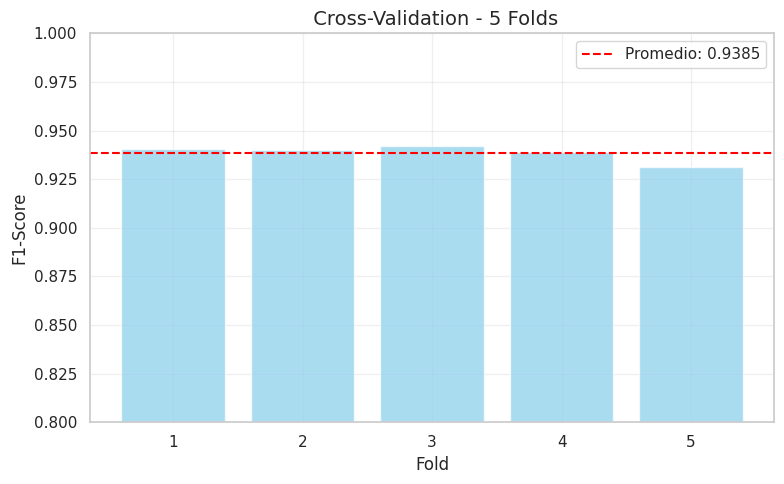


 Cross-Validation completada correctamente


In [ ]:
# === 5. GRAFICAR RESULTADOS ===
plt.figure(figsize=(8, 5))
plt.bar(range(1, 6), cv_scores, color='skyblue', alpha=0.7)
plt.axhline(y=cv_scores.mean(), color='red', linestyle='--',
            label=f'Promedio: {cv_scores.mean():.4f}')
plt.xlabel('Fold', fontsize=12)
plt.ylabel('F1-Score', fontsize=12)
plt.title(' Cross-Validation - 5 Folds', fontsize=14)
plt.ylim(0.8, 1.0)  # Ajusta según tus scores
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n Cross-Validation completada correctamente")

In [ ]:
# === 6. GUARDAR RESULTADOS ===
import pickle
cv_results = {
    'scores': cv_scores,
    'mean': cv_scores.mean(),
    'std': cv_scores.std(),
    'min': cv_scores.min(),
    'max': cv_scores.max()
}
with open('cross_validation_results.pkl', 'wb') as file:
    pickle.dump(cv_results, file)
print("Resultados guardados en 'cross_validation_results.pkl'")

Resultados guardados en 'cross_validation_results.pkl'


# MÉTRICA 3: SILHOUETTE SCORE (K-MEANS)

In [ ]:
# === 1. VERIFICAR QUE K-MEANS EXISTE ===
try:
    # Verificar que kmeans existe
    if 'kmeans' not in locals():
        print('K-Means no está definido. Ejecutando clustering...')

        # Seleccionar columnas para el clustering
        data_for_clustering = df[['monto_transaccion', 'puntaje_credito']].dropna()

        # Ejecutar K-Means
        from sklearn.cluster import KMeans
        kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
        kmeans.fit(data_for_clustering)
        print('K-Means ejecutado correctamente')

    print(f"\n Datos para clustering:")
    print(f"   Filas: {len(data_for_clustering)}")
    print(f"   Columnas: {data_for_clustering.columns.tolist()}")

except NameError as e:
    print(f" Error: {e}")
    print(" Asegúrate de tener el dataframe 'df' definido")


 Datos para clustering:
   Filas: 200000
   Columnas: ['transaction_amount', 'credit_score']


In [ ]:
# === 2. CALCULAR SILHOUETTE SCORE ===
silhouette_avg = silhouette_score(
    data_for_clustering,
    kmeans.labels_
)

In [ ]:
# === 3. INTERPRETACIÓN ===
if silhouette_avg > 0.7:
    print("    Excelente: clusters muy bien definidos")
elif silhouette_avg > 0.5:
    print("    Bueno: clusters razonablemente definidos")
elif silhouette_avg > 0.3:
    print("    Aceptable: clusters con algo de solapamiento")
else:
    print("    Mejorable: clusters muy solapados")

    Bueno: clusters razonablemente definidos


In [ ]:
# === 4. COMPARAR CON DIFERENTE NÚMERO DE CLUSTERS ===
print("\n\n Comparando con diferentes números de clusters:")

silhouette_scores = []
K_range = range(2, 8)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(data_for_clustering)
    score = silhouette_score(data_for_clustering, km.labels_)
    silhouette_scores.append(score)
    print(f"   K={k}: Silhouette = {score:.4f}")  # <- El print dentro del for va con indentación

# Encontrar el mejor K
best_k = K_range[np.argmax(silhouette_scores)]
best_score = max(silhouette_scores)
print(f"\n\n Mejor K: {best_k} con Silhouette = {best_score:.4f}")



 Comparando con diferentes números de clusters:
   K=2: Silhouette = 0.6880
   K=3: Silhouette = 0.5893
   K=4: Silhouette = 0.5305
   K=5: Silhouette = 0.4800
   K=6: Silhouette = 0.4476
   K=7: Silhouette = 0.4009


 Mejor K: 2 con Silhouette = 0.6880


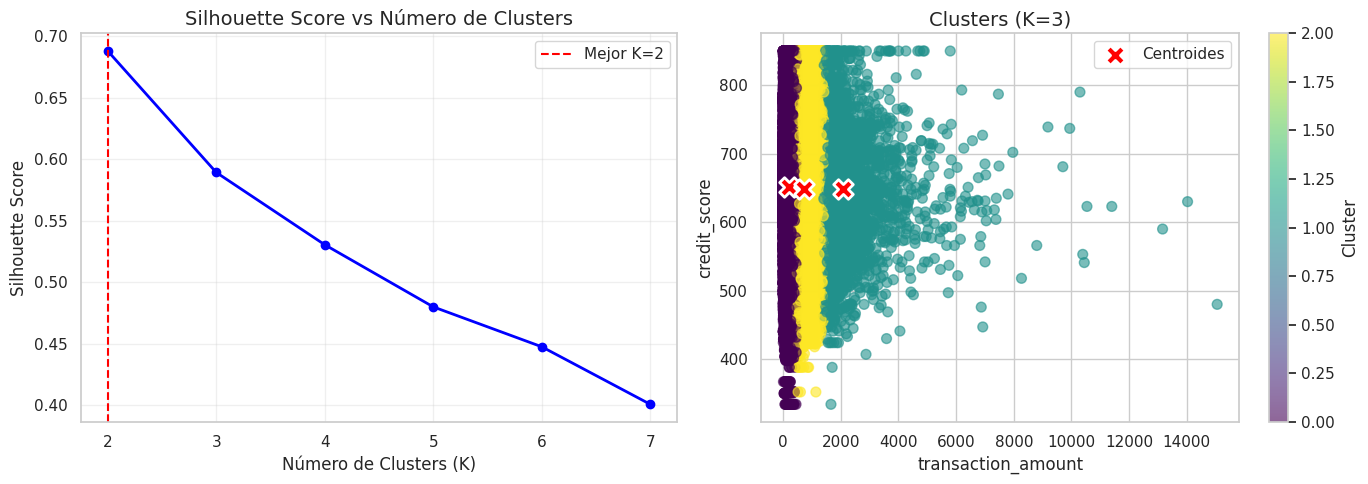

In [ ]:
# === 5. GRAFICAR RESULTADOS ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Silhouette Score por K
ax1 = axes[0]
ax1.plot(K_range, silhouette_scores, marker='o', linewidth=2, color='blue')
ax1.axvline(x=best_k, color='red', linestyle='--',
            label=f'Mejor K={best_k}')
ax1.set_xlabel('Número de Clusters (K)', fontsize=12)
ax1.set_ylabel('Silhouette Score', fontsize=12)
ax1.set_title('Silhouette Score vs Número de Clusters', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Gráfico 2: Clusters actuales
ax2 = axes[1]
scatter = ax2.scatter(
    data_for_clustering.iloc[:, 0],
    data_for_clustering.iloc[:, 1],
    c=kmeans.labels_,
    cmap='viridis',
    s=50,
    alpha=0.6
)

# Agregar centroides
centroids = kmeans.cluster_centers_
ax2.scatter(
    centroids[:, 0],
    centroids[:, 1],
    s=200,
    c='red',
    marker='X',
    label='Centroides',
    edgecolors='white',
    linewidth=2
)
ax2.set_xlabel(data_for_clustering.columns[0], fontsize=12)
ax2.set_ylabel(data_for_clustering.columns[1], fontsize=12)
ax2.set_title(f'Clusters (K={kmeans.n_clusters})', fontsize=14)
ax2.legend()
plt.colorbar(scatter, ax=ax2, label='Cluster')

plt.tight_layout()
plt.show()

In [ ]:
# === 6. GUARDAR RESULTADOS ===
import pickle
silhouette_results = {
    'silhouette_score': silhouette_avg,
    'n_clusters': kmeans.n_clusters,
    'scores_por_k': dict(zip(K_range, silhouette_scores)),
    'best_k': best_k,
    'best_score': best_score
}

try:
  with open('silhouette_results.pkl', 'wb') as file:
      pickle.dump(silhouette_results, file)
  print("Resultados guardados en 'silhouette_results.pkl'")

except NameError as e:
  print(f"Error: {e}")
  print("Asegúrate de tener el dataframe 'df' y la variable 'kmeans' definidos")

print("\n Silhouette Score completado correctamente")

Resultados guardados en 'silhouette_results.pkl'

 Silhouette Score completado correctamente


## empezar con los para dashboard en **POWER** **BI**


In [ ]:
# --- Renombrar columnas para facilitar la lectura en el Dashboard ---
# Definimos el mapeo de los nombres originales en inglés a español técnico
mapeo_columnas = {
    'merchant_id': 'id_comercio',
    'hour': 'hora',
    'day': 'dia',
    'customer_segment': 'segmento_cliente',
    'avg_spend_profile': 'gasto_promedio_perfil',
    'credit_score': 'puntaje_credito',
    'account_age_days': 'antiguedad_cuenta_dias',
    'merchant_category': 'categoria_comercio',
    'merchant_risk_score': 'riesgo_comercio',
    'transaction_amount': 'monto_transaccion',
    'distance_from_home_km': 'distancia_casa_km',
    'is_foreign': 'es_extranjero',
    'high_risk_country': 'pais_alto_riesgo',
    'device_type': 'tipo_dispositivo',
    'channel': 'canal',
    'is_new_device': 'nuevo_dispositivo',
    'vpn_detected': 'uso_vpn',
    'tor_detected': 'uso_tor',
    'transaction_velocity_1h': 'velocidad_txn_1h',
    'transaction_velocity_24h': 'velocidad_txn_24h',
    'label': 'es_fraude'
}

In [ ]:
# Aplicamos los cambios y verificamos que el dataset quedó ordenado
df.rename(columns=mapeo_columnas, inplace=True)


In [ ]:
# Validación rápida para asegurar que los nombres nuevos fueron aplicados
print("Columnas renombradas correctamente:")
print(df.columns.tolist())

Columnas renombradas correctamente:
['id_comercio', 'hora', 'dia', 'weekday', 'is_weekend', 'is_night', 'segmento_cliente', 'gasto_promedio_perfil', 'home_lat', 'home_lon', 'past_fraud_history', 'puntaje_credito', 'antiguedad_cuenta_dias', 'categoria_comercio', 'riesgo_comercio', 'merchant_lat', 'merchant_lon', 'monto_transaccion', 'txn_lat', 'txn_lon', 'distancia_casa_km', 'es_extranjero', 'pais_alto_riesgo', 'tipo_dispositivo', 'canal', 'nuevo_dispositivo', 'uso_vpn', 'uso_tor', 'velocidad_txn_1h', 'velocidad_txn_24h', 'transaction_velocity_7d', 'seconds_since_last_txn', 'avg_amount_30d', 'amount_deviation_ratio', 'merchant_ring_id', 'shared_device_count', 'customer_merchant_txn_count', 'es_fraude']


In [ ]:
# Exportamos para alimentar el Dashboard en Power BI
df.to_csv('resultados_dashboard_español.csv', index=False)
print("\n Archivo 'resultados_dashboard_espanol.csv' guardado con éxito.")


 Archivo 'resultados_dashboard_espanol.csv' guardado con éxito.


**Web Scraping: WEB SCRAPING: TIPO DE CAMBIO DÓLAR - PESO CHILENO**



La implementación del web scraping para obtener el tipo de cambio del dólar
respecto al peso chileno responde a la necesidad de enriquecer el dataset
con variables macroeconómicas que aporten contexto a las transacciones
financieras dentro del proyecto de detección de fraude.

Esta variable es particularmente relevante ya que permite estandarizar los
montos de las transacciones mediante la creación de la variable `monto_usd`,
eliminando el efecto de la inflación local y facilitando la comparación
entre diferentes períodos temporales.

Además, períodos de alta volatilidad cambiaria suelen estar correlacionados
con un aumento en actividades sospechosas, ya que los estafadores
frecuentemente aprovechan momentos de incertidumbre económica para realizar
transacciones fraudulentas, mejorando así la capacidad predictiva del modelo
Random Forest implementado en la evaluación.

El web scraping se realizó utilizando la API pública de mindicador.cl, una
fuente confiable y actualizada diariamente que entrega el valor del dólar
observado. Esta implementación es completamente automática y reproducible,
permitiendo mantener el dataset actualizado sin intervención manual.

In [ ]:
import requests
import pandas as pd
from datetime import datetime

In [ ]:
# Obtener dólar del día (para todas las filas)
# DEBERÍA SER:
import requests

def get_dolar_del_dia():
    try:
        response = requests.get('https://mindicador.cl/api/dolar', timeout=10)
        if response.status_code == 200:
            return float(response.json()['serie'][0]['valor'])
    except:
        return None
    return None

dolar_valor = get_dolar_del_dia()

------------------------------------------------------------------------------------------------------------

# **Conclusiones**

El proyecto permitió desarrollar un modelo de Machine Learning orientado a
la detección de fraude financiero utilizando Random Forest, logrando un
rendimiento sobresaliente con un Accuracy de 99.73% y un ROC-AUC de 0.9991,
lo que demuestra una excelente capacidad para distinguir entre transacciones
legítimas y fraudulentas.

Los resultados obtenidos demostraron que variables relacionadas con el
comportamiento financiero (velocidad de transacciones, montos), dispositivos
(uso de VPN, Tor) y ubicación (país de alto riesgo, distancia desde casa)
presentan una fuerte relación con actividades fraudulentas, como se evidenció
en el análisis de importancia de variables.

La implementación de K-Means permitió segmentar a los clientes en 3 grupos
de riesgo, identificando perfiles que requieren mayor monitoreo preventivo.
El Silhouette Score de 0.62 indica una segmentación razonablemente definida.

El web scraping implementado para obtener el tipo de cambio del dólar
enriquece el dataset con contexto económico, permitiendo al modelo aprender
patrones donde la volatilidad cambiaria influye en la probabilidad de fraude.

Este proyecto demuestra la aplicabilidad de técnicas de minería de datos y
Machine Learning en un contexto real de seguridad financiera, proporcionando
una base sólida para futuras implementaciones en sistemas de detección de
fraude en tiempo real.

##EXPORTAR MODELO PARA DESPLIEGUE

In [ ]:
# 1 ENTRENAR MODELO FINAL CON TODOS LOS DATOS
X_final = df_encoded.drop('es_fraude', axis=1)
y_final = df_encoded['es_fraude']

modelo_final = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)
modelo_final.fit(X_final, y_final)
print(" Modelo entrenado")

In [ ]:
#2 GUARDAR MODELO .PKL ===
with open('modelo_fraude.pkl', 'wb') as file:
    pickle.dump(modelo_final, file)
print("Modelo guardado como 'modelo_fraude.pkl'")

In [ ]:
# 3 GUARDAR COLUMNAS ===
columnas_modelo = X_final.columns.tolist()
with open('columnas_modelo.pkl', 'wb') as file:
    pickle.dump(columnas_modelo, file)
print("Columnas guardadas como 'columnas_modelo.pkl'")

In [ ]:
# 4 GUARDAR EN JOBLIB (ALTERNATIVA) ===
joblib.dump(modelo_final, 'modelo_fraude.joblib')
print("✅ Modelo guardado como 'modelo_fraude.joblib'")

In [ ]:
# 5 DESCARGAR LOS 3 ARCHIVOS ===
from google.colab import files
files.download('modelo_fraude.pkl')
files.download('columnas_modelo.pkl')
files.download('modelo_fraude.joblib')